In [2]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import mnist

In [3]:
((train_images,train_labels),(test_images,test_labels))= mnist.load_data()

In [5]:
train_images= train_images/255.0
test_images= test_images/255.0

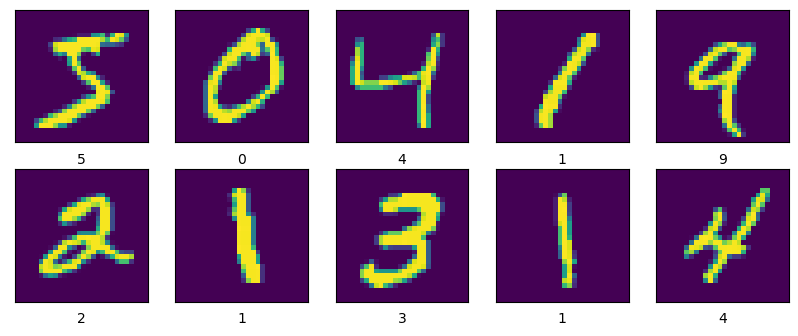

In [8]:
#showing images of mentioned categories
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(train_labels[i])
plt.show()

In [9]:
#defining model architecture

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 3, 3, 64)          36928     
                                                                 
 flatten (Flatten)           (None, 576)               0

In [10]:
#training model
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy'])

epochs = 10
h = model.fit(train_images, train_labels, epochs=epochs,validation_data=(test_images, test_labels))


Epoch 1/10
1875/1875 [==============================] - 45s 22ms/step - loss: 0.7962 - accuracy: 0.7254 - val_loss: 0.2768 - val_accuracy: 0.9126
Epoch 2/10
1875/1875 [==============================] - 42s 23ms/step - loss: 0.2431 - accuracy: 0.9240 - val_loss: 0.1757 - val_accuracy: 0.9452
Epoch 3/10
1875/1875 [==============================] - 42s 23ms/step - loss: 0.1631 - accuracy: 0.9486 - val_loss: 0.1176 - val_accuracy: 0.9641
Epoch 4/10
1875/1875 [==============================] - 48s 25ms/step - loss: 0.1262 - accuracy: 0.9601 - val_loss: 0.1154 - val_accuracy: 0.9639
Epoch 5/10
1875/1875 [==============================] - 48s 26ms/step - loss: 0.1047 - accuracy: 0.9663 - val_loss: 0.0848 - val_accuracy: 0.9725
Epoch 6/10
1875/1875 [==============================] - 48s 26ms/step - loss: 0.0899 - accuracy: 0.9714 - val_loss: 0.0735 - val_accuracy: 0.9763
Epoch 7/10
1875/1875 [==============================] - 46s 24ms/step - loss: 0.0793 - accuracy: 0.9748 - val_loss: 0.0757 -

In [11]:
predicted_values = model.predict(test_images)
predicted_values.shape

313/313 [==============================] - 3s 8ms/step


(10000, 10)

Text(0.5, 1.0, '6')

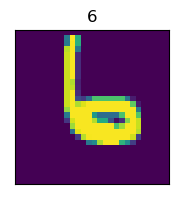

In [17]:
import random
import numpy as np
plt.figure(figsize=(2,2))
n = random.randint(0,9999)
#plt.figure(figsize=(10,10))
plt.imshow(test_images[n])
plt.xticks([])
plt.yticks([])
plt.grid(False)
plt.title(np.argmax(predicted_values[n]))

In [12]:
test_loss,test_acc = model.evaluate(test_images,test_labels)
print("loss %.3f"%test_loss)
print("acc %.3f"%test_acc)


313/313 [==============================] - 3s 8ms/step - loss: 0.0676 - accuracy: 0.9804
loss 0.068
acc 0.980
